## Data Cleaning & Data Exploration 

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt

def load_data(file_path):
    """Load data from a csv file"""
    return pd.read_csv(file_path, encoding = 'latin1')

PATH: str = '/Users/nathandouieb/Desktop/FinalProjectV3/data/raw/softDrinks.csv'
data = load_data(file_path = PATH)

print(data.shape)
data.head(3)

(17476933, 14)


,UPC,STORE,WEEK,MOVE,QTY,PRICE,SALE,PROFIT,OK,COM_CODE,DESCRIP,SIZE,CASE,NITEM
0,179.0,2,1,1,1,10.0,NaN,99.9,1,225,BLOOD GLUCOSE SCREEN,EACH,1,9990290
1,179.0,2,2,0,1,0.0,NaN,0.0,1,225,BLOOD GLUCOSE SCREEN,EACH,1,9990290
2,179.0,2,3,0,1,0.0,NaN,0.0,1,225,BLOOD GLUCOSE SCREEN,EACH,1,9990290


In [2]:
# Keep only rows where OK is 1
try:
    data = data[data.OK == 1]            
    data = data.drop(columns = ['OK', 'NITEM', 'CASE'], axis = 1)
    print('Columns deleted.')
except:
    print("Columns still deleted or doesn't exist.")

data_no_prom = data[data.SALE.isna()]                       # Data without promotion
print(f'Data no promotion shape: {data_no_prom.shape}')

data_prom = data[data.SALE == 'S']                          # Data with simple promotion
print(f'Data simple promotion shape: {data_prom.shape}')

Columns deleted.
Data no promotion shape: (14053282, 11)
Data simple promotion shape: (1660917, 11)


In [3]:
# Keep Relevant Columns
data_no_prom = data_no_prom[['UPC', 'STORE', 'WEEK', 'PRICE', 'MOVE']]
data_prom = data_prom[['UPC', 'STORE', 'WEEK', 'PRICE', 'MOVE']]

# Check on specific product (the higther) & Specific Store
data_no_prom = data_no_prom[(data_no_prom.UPC == data_prom.UPC.value_counts().index[0]) & (data_no_prom.STORE == 2)]
data_prom = data_prom[(data_prom.UPC == data_prom.UPC.value_counts().index[0]) & (data_prom.STORE == 2)]

# Add column promotion or Not
data_no_prom['Promotion'] = 0
data_prom['Promotion'] = 1

# Concat & Order weeks
data_concat = pd.concat((data_no_prom, data_prom)).sort_values(by = 'WEEK', ascending = True).reset_index(drop = True)
print(data_concat.shape)
data_concat.tail(3)

(311, 6)


,UPC,STORE,WEEK,PRICE,MOVE,Promotion
308,1.200000e+09,2,397,1.09,78,1
309,1.200000e+09,2,398,1.67,40,0
310,1.200000e+09,2,399,1.69,46,0


### Add Discount

To find the discount we need to check if there has been a change compared to the previous week's price, and if so, by how much.

To calculate the ratio, we will use: `np.ceil((((t -1) - t) / (t - 1)) * 100)`

In [7]:
# Shift all by 1
data_concat['Price_Prev'] = data_concat.groupby(['UPC', 'STORE'])['PRICE'].shift(1)

# Discount -> # np.ceil((((t -1) - t) / (t - 1)) * 100)
data_concat['Discount'] = np.where(data_concat['Promotion'] == 1, ((data_concat['Price_Prev'] - data_concat['PRICE']) / data_concat['Price_Prev']) * 100, 0)
data_concat['Discount'] = np.where(data_concat['Discount'] < 0, 0, data_concat['Discount'])

print(data_concat.shape)
data_concat.tail(3)

(311, 8)


,UPC,STORE,WEEK,PRICE,MOVE,Promotion,Price_Prev,Discount
308,1.200000e+09,2,397,1.09,78,1,1.69,35.502959
309,1.200000e+09,2,398,1.67,40,0,1.09,0.000000
310,1.200000e+09,2,399,1.69,46,0,1.67,0.000000


In [12]:
data_concat.WEEK.unique()

array([  1,   2,   3,   5,   7,   8,   9,  10,  11,  12,  14,  17,  19,
        20,  22,  24,  26,  28,  29,  31,  32,  34,  35,  37,  38,  40,
        42,  43,  44,  46,  47,  48,  51,  53,  54,  57,  58,  60,  61,
        62,  63,  64,  67,  68,  69,  71,  72,  74,  76,  77,  78,  80,
        81,  82,  83,  85,  86,  87,  89,  90,  91,  92,  93,  94,  97,
        99, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114,
       115, 116, 117, 118, 119, 121, 122, 123, 124, 125, 126, 127, 128,
       129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141,
       142, 143, 144, 145, 146, 148, 149, 150, 151, 152, 153, 154, 156,
       157, 158, 159, 161, 163, 164, 165, 166, 167, 168, 169, 170, 173,
       174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186,
       187, 188, 189, 192, 193, 194, 195, 196, 197, 202, 203, 204, 205,
       206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218,
       220, 221, 222, 223, 226, 227, 228, 229, 230, 231, 232, 23

In [9]:
data_concat[data_concat.WEEK == 399]

,UPC,STORE,WEEK,PRICE,MOVE,Promotion,Price_Prev,Discount
310,1.200000e+09,2,399,1.69,46,0,1.67,0.0


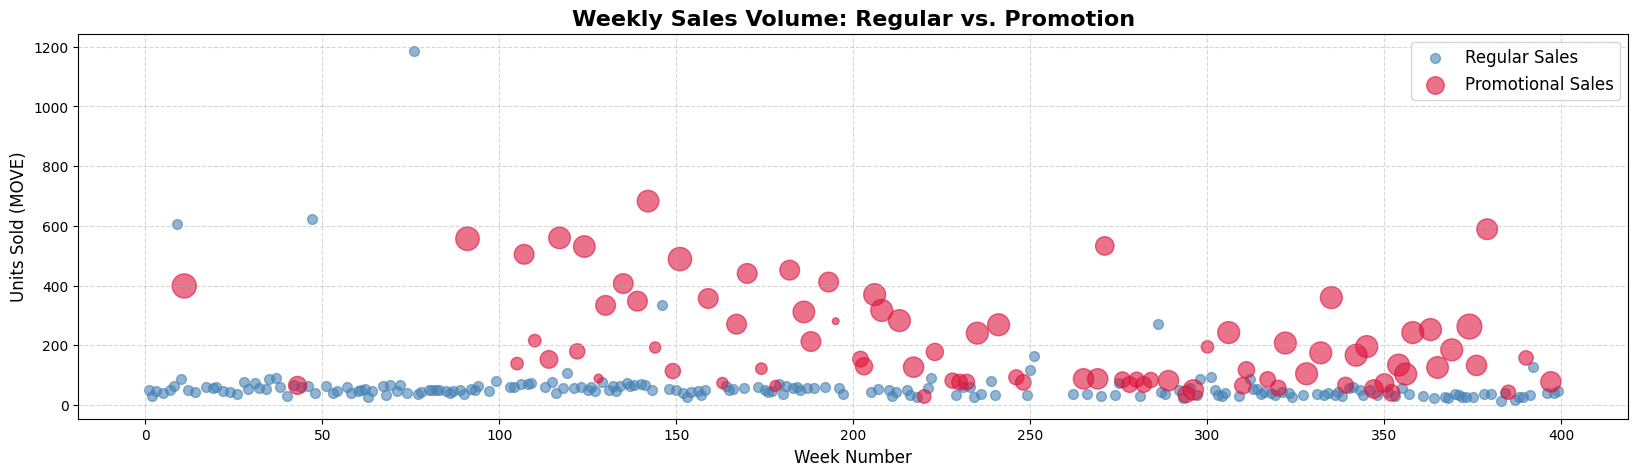

In [8]:
plt.figure(figsize = (20, 5))
plt.scatter(data_concat[data_concat.Promotion == 0].WEEK, data_concat[data_concat.Promotion == 0].MOVE, label = 'Regular Sales', color = 'steelblue', alpha = 0.6, s = 50)
plt.scatter(data_concat[data_concat.Promotion == 1].WEEK, data_concat[data_concat.Promotion == 1].MOVE, label = 'Promotional Sales',
             color = 'crimson', alpha = 0.6, s = data_concat[data_concat.Promotion == 1].Discount * 6)
plt.title('Weekly Sales Volume: Regular vs. Promotion', fontsize=16, fontweight='bold')
plt.xlabel('Week Number', fontsize = 12)
plt.ylabel('Units Sold (MOVE)', fontsize = 12)
plt.legend(fontsize = 12)
plt.grid(True, linestyle='--', alpha = 0.5)

plt.savefig('/Users/nathandouieb/Desktop/FinalProjectV3/src/visualization/SalesVolume.png')
plt.show()

**First Impressions**
* Without a sale, a stable sales level is observed, which is an approximation of the basic demand.
* During sale periods, a significant positive deviation from the basic demand is observed, depending on the intensity of the sale.
* Weeks with a sale are colored red, with the size of the circle being in proportion to the size of the sale.
* Outliers that do not represent current demand were identified and removed for the purpose of estimating a baseline without bias.

In [6]:
# Save Data
PATH_SAVE: str = '/Users/nathandouieb/Desktop/FinalProjectV3/data/processed/data_cleaned.xlsx'
data_concat.to_excel(PATH_SAVE, header = True)
print('Data Successfully loaded to:', PATH_SAVE)

Data Successfully loaded to: /Users/nathandouieb/Desktop/FinalProjectV3/data/processed/data_cleaned.xlsx
